In [2]:
import sys
import os
import numpy as np 
import pandas as pd

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../..')))

from utilities.log_processor import LogProcessor

import matplotlib.pyplot as plt

In [3]:
processor = LogProcessor('../../logs/nothingbot@16_03_2025_1321.log')
processor.read_log()

In [4]:
df = processor.activites_log
df.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,RAINFOREST_RESIN,10002,1,9996.0,2.0,9995.0,29.0,10004,2,10005.0,29.0,NaN,NaN,10003.0,0.0
1,-1,0,KELP,2028,1,2026.0,2.0,2025.0,29.0,2029,31,NaN,NaN,NaN,NaN,2028.5,0.0
2,-1,100,KELP,2025,24,NaN,NaN,NaN,NaN,2028,2,2029.0,22.0,NaN,NaN,2026.5,0.0
3,-1,100,RAINFOREST_RESIN,9996,2,9995.0,22.0,NaN,NaN,10004,2,10005.0,22.0,NaN,NaN,10000.0,0.0
4,-1,200,RAINFOREST_RESIN,9995,20,NaN,NaN,NaN,NaN,10005,20,NaN,NaN,NaN,NaN,10000.0,0.0


In [5]:
kelp_data = df[df['product']=="KELP"].reset_index()
resin_data = df[df['product']=="RAINFOREST_RESIN"].reset_index()

## Perfect Traders to be explored:
- Type 1: Trades maximally based on prevailing midprice using future knowledge

- Type 2.1 : Able to make the spread with maximal theo position at every single timestamp (i.e. buys bid and sells ask at the position max at every timestamp)

- Type 2.2 : Able to make the spread with maximal actual position at every single timestamp (i.e. buys bid and sells ask at the volumes at every timestamp)

### Type 1 Midprice

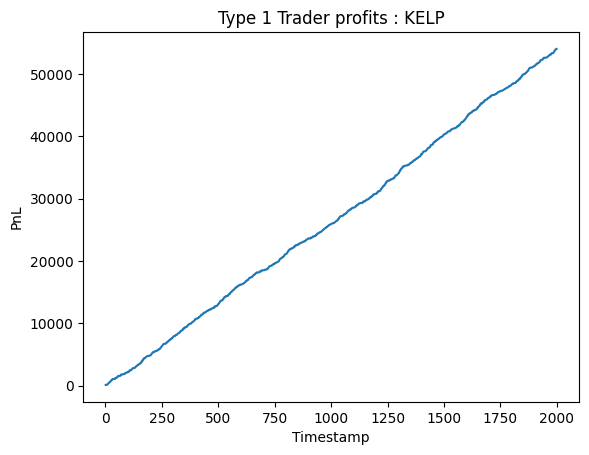

In [11]:
mid_price_data = kelp_data.mid_price
cumulative_profit = abs(mid_price_data.diff() * 50).cumsum()
plt.plot(cumulative_profit)
plt.title('Type 1 Trader profits : KELP')
plt.xlabel('Timestamp')
plt.ylabel('PnL')
plt.show()

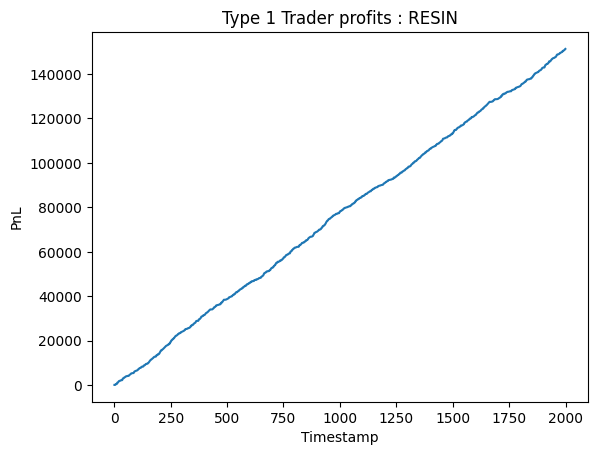

In [12]:
mid_price_data = resin_data.mid_price
cumulative_profit = abs(mid_price_data.diff() * 50).cumsum()
plt.plot(cumulative_profit)
plt.title('Type 1 Trader profits : RESIN')
plt.xlabel('Timestamp')
plt.ylabel('PnL')
plt.show()

### Type 2.1 Maximal Optimal MM

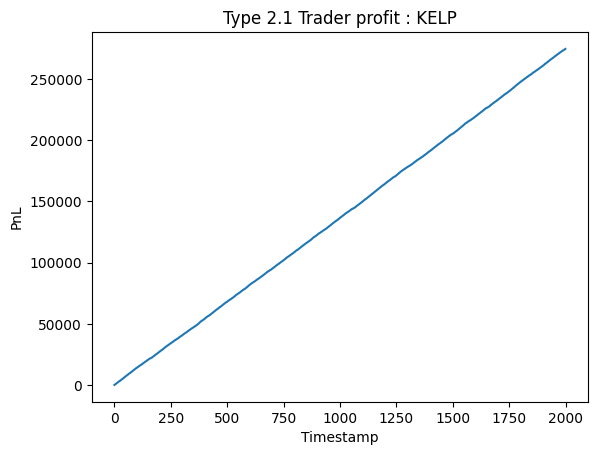

In [16]:
pnl = ((kelp_data.ask_price_1-kelp_data.bid_price_1)*50).cumsum()
plt.plot(pnl)
plt.title("Type 2.1 Trader profit : KELP")
plt.xlabel('Timestamp')
plt.ylabel("PnL")
plt.show()

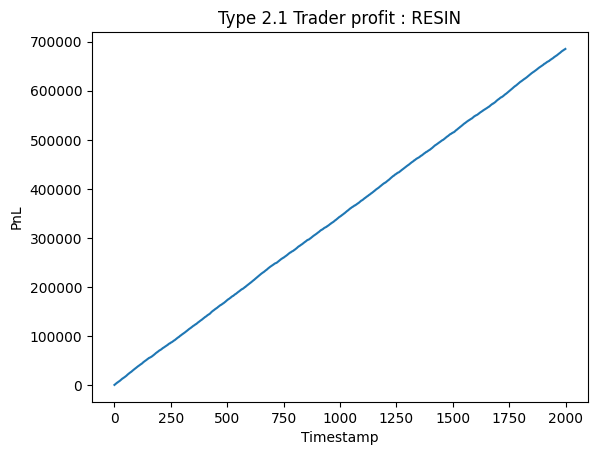

In [15]:
pnl = ((resin_data.ask_price_1-resin_data.bid_price_1)*50).cumsum()
plt.plot(pnl)
plt.title("Type 2.1 Trader profit : RESIN")
plt.xlabel('Timestamp')
plt.ylabel("PnL")
plt.show()

### Type 2.2 : Non-maximal optimal MM

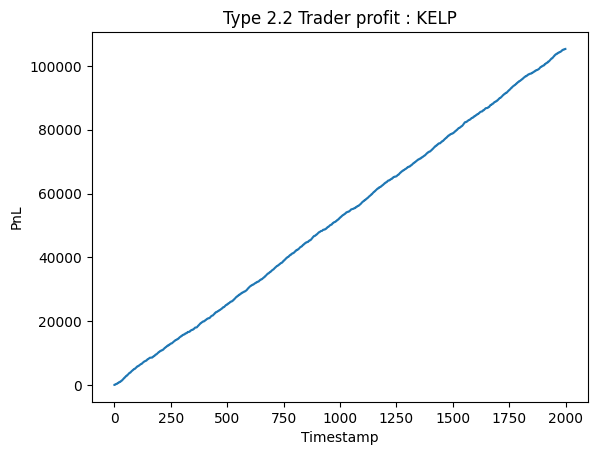

In [ ]:
min_vol = kelp_data.apply(lambda row: min(row['ask_volume_1'],row['bid_volume_1']), axis=1)
pnl = ((kelp_data.ask_price_1-kelp_data.bid_price_1)*min_vol).cumsum()
plt.plot(pnl)
plt.title("Type 2.2 Trader profit : KELP")
plt.xlabel('Timestamp')
plt.ylabel("PnL")
plt.show()

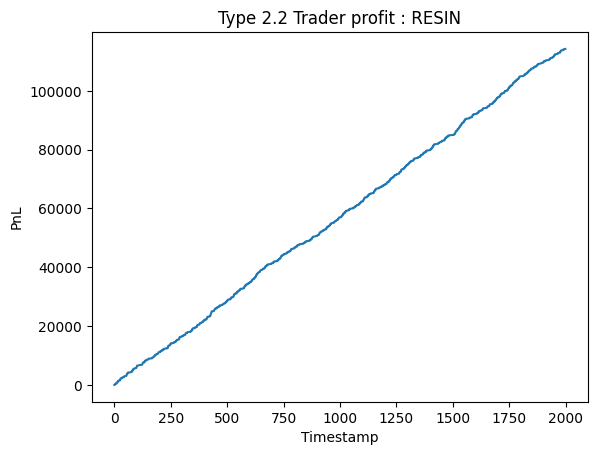

In [21]:
min_vol = resin_data.apply(lambda row: min(row['ask_volume_1'],row['bid_volume_1']), axis=1)
pnl = ((resin_data.ask_price_1-resin_data.bid_price_1)*min_vol).cumsum()
plt.plot(pnl)
plt.title("Type 2.2 Trader profit : RESIN")
plt.xlabel('Timestamp')
plt.ylabel("PnL")
plt.show()

The very rough ceiling for profits on kelp is around 50k, and for resin it's 100k.